# 3. FEATURE ENGINEERING
## Daily Customer Churn Predictor · VivaMarket Brasil

---

**INPUT:** `../data/raw/churn_sqlite_db.sqlite` and `../data/interim/client_database_clean_YYYYMMDD.parquet`

*The relational ecommerce source plus the cleaned customer-level base created in NB01.*

**OUTPUT:** `../data/processed/churn_features_YYYYMMDD.parquet`

*A modeling-ready customer-snapshot feature matrix with historical behavioral features and a forward 90-day churn label.*

---
## 3.1. STARTING SITUATION

NB01 converted the raw SQLite structure into a stable cleaned customer base, and NB02 showed that churn behavior in this marketplace is strongly linked to inactivity, low purchase frequency and temporal concentration of demand. The next step is to transform those findings into a reproducible feature matrix that a modeling notebook can consume without rebuilding business logic from scratch.

This notebook therefore moves from **understanding churn dynamics** to **encoding those dynamics as variables**. The goal is not only to create totals, but to capture how recent, frequent, valuable and operationally healthy each customer relationship looks at a given snapshot date.

---
## 3.2. NOTEBOOK OBJECTIVE

- **Business objective:** transform customer purchase history into a churn-prediction feature base that can support daily scoring and retention prioritization.
- **Analytical objective:** generate customer-snapshot observations with rolling historical features and a forward 90-day churn label, ready for model training in NB04.

---
## 3.3. INITIAL SETUP

**What is done**

We import the libraries required for feature engineering, reproducible path handling, logging, relational extraction and lightweight visualization.

**Why it is done**

NB03 needs to be stable across environments and transparent enough to audit. Explicit logging also helps identify where a feature pipeline fails if the logic becomes more complex over time.

**Expected result**

A clean execution environment with resolved project paths, active logging and output directories ready to store the engineered dataset.

In [1]:
import logging
import sqlite3
from datetime import datetime
from zoneinfo import ZoneInfo
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    force=True,
)
logger = logging.getLogger('nb03_feature_engineering')
logger.info('NB03 started: feature engineering.')

sns.set_theme(style='whitegrid', context='talk')

2026-05-02 00:10:50,781 | INFO | NB03 started: feature engineering.


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
RAW_DB_PATH = PROJECT_ROOT / 'data' / 'raw' / 'churn_sqlite_db.sqlite'
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

latest_interim_path = max(INTERIM_DIR.glob('client_database_clean_*.parquet'), default=None)
run_date_tag = datetime.now(ZoneInfo('Europe/Paris')).strftime('%Y%m%d')
output_path = PROCESSED_DIR / f'churn_features_{run_date_tag}.parquet'

logger.info('Project root resolved at %s', PROJECT_ROOT)
logger.info('Raw database path resolved at %s', RAW_DB_PATH)
logger.info('Latest interim path: %s', latest_interim_path)
logger.info('Processed output path: %s', output_path)

2026-05-02 00:10:50,789 | INFO | Project root resolved at /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor


2026-05-02 00:10:50,790 | INFO | Raw database path resolved at /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor/data/raw/churn_sqlite_db.sqlite


2026-05-02 00:10:50,791 | INFO | Latest interim path: /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor/data/interim/client_database_clean_20260429.parquet


2026-05-02 00:10:50,792 | INFO | Processed output path: /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor/data/processed/churn_features_20260502.parquet


---
## 3.4. DATA LOADING AND ORDER-LEVEL ENRICHMENT

**What is done**

We rebuild an order-level analytical layer by joining orders with customer identity, commercial amounts, review quality and product-category information.

**Why it is done**

The customer-level interim base is useful for orientation, but feature engineering needs order-grain history to create rolling windows, payment-mix signals, delivery-quality indicators and forward labels.

**Expected result**

A single enriched order table where each order contributes temporal, monetary, operational and category information to later customer-snapshot aggregation.

In [3]:
with sqlite3.connect(RAW_DB_PATH) as connection:
    orders = pd.read_sql_query(
        '''
        SELECT
            o.order_id,
            o.customer_id,
            c.customer_unique_id,
            c.customer_state,
            o.order_status,
            o.order_purchase_timestamp,
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        FROM orders AS o
        INNER JOIN customers AS c
            ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        ''',
        connection,
        parse_dates=[
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date',
        ],
    )

    order_items = pd.read_sql_query(
        '''
        SELECT
            oi.order_id,
            COUNT(*) AS items_n,
            COUNT(DISTINCT oi.product_id) AS distinct_products_n,
            SUM(oi.price) AS total_item_price,
            SUM(oi.freight_value) AS total_freight_value,
            COUNT(DISTINCT COALESCE(t.product_category_name_english, p.product_category_name, 'unknown')) AS distinct_categories_n
        FROM order_items AS oi
        LEFT JOIN products AS p
            ON oi.product_id = p.product_id
        LEFT JOIN product_category_name_translation AS t
            ON p.product_category_name = t.product_category_name
        GROUP BY oi.order_id
        ''',
        connection,
    )

    payments = pd.read_sql_query(
        '''
        SELECT
            order_id,
            SUM(payment_value) AS total_payment_value,
            MAX(payment_installments) AS max_installments,
            COUNT(DISTINCT payment_type) AS payment_type_nunique,
            SUM(CASE WHEN payment_type = 'credit_card' THEN payment_value ELSE 0 END) AS credit_card_value,
            SUM(CASE WHEN payment_type = 'boleto' THEN payment_value ELSE 0 END) AS boleto_value,
            SUM(CASE WHEN payment_type = 'voucher' THEN payment_value ELSE 0 END) AS voucher_value,
            SUM(CASE WHEN payment_type = 'debit_card' THEN payment_value ELSE 0 END) AS debit_card_value
        FROM order_payments
        GROUP BY order_id
        ''',
        connection,
    )

    reviews = pd.read_sql_query(
        '''
        SELECT
            order_id,
            AVG(review_score) AS avg_review_score
        FROM order_reviews
        GROUP BY order_id
        ''',
        connection,
    )

logger.info('Loaded %s order rows from SQLite.', len(orders))
logger.info('Loaded %s item aggregates, %s payment aggregates and %s review aggregates.', len(order_items), len(payments), len(reviews))

2026-05-02 00:10:52,654 | INFO | Loaded 99441 order rows from SQLite.


2026-05-02 00:10:52,655 | INFO | Loaded 98666 item aggregates, 99440 payment aggregates and 98673 review aggregates.


In [4]:
order_level_df = (
    orders
    .merge(order_items, on='order_id', how='left')
    .merge(payments, on='order_id', how='left')
    .merge(reviews, on='order_id', how='left')
)

numeric_fill_columns = [
    'items_n',
    'distinct_products_n',
    'total_item_price',
    'total_freight_value',
    'distinct_categories_n',
    'total_payment_value',
    'max_installments',
    'payment_type_nunique',
    'credit_card_value',
    'boleto_value',
    'voucher_value',
    'debit_card_value',
    'avg_review_score',
]

for column in numeric_fill_columns:
    order_level_df[column] = order_level_df[column].fillna(0)

order_level_df['delivery_delay_days'] = (
    (order_level_df['order_delivered_customer_date'] - order_level_df['order_estimated_delivery_date'])
    .dt.total_seconds()
    .div(86400)
)
order_level_df['delivery_delay_days'] = order_level_df['delivery_delay_days'].fillna(0)
order_level_df['delivered_flag'] = (order_level_df['order_status'] == 'delivered').astype(int)
order_level_df['purchase_date'] = order_level_df['order_purchase_timestamp'].dt.floor('D')

logger.info('Order-level analytical layer created with shape %s.', order_level_df.shape)
order_level_df.head()

2026-05-02 00:10:52,751 | INFO | Order-level analytical layer created with shape (99441, 24).


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,items_n,distinct_products_n,...,max_installments,payment_type_nunique,credit_card_value,boleto_value,voucher_value,debit_card_value,avg_review_score,delivery_delay_days,delivered_flag,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1.0,1.0,...,1.0,2.0,18.12,0.00,20.59,0.0,4.0,-7.107488,1,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,BA,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1.0,1.0,...,1.0,1.0,0.00,141.46,0.00,0.0,4.0,-5.355729,1,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1.0,1.0,...,3.0,1.0,179.12,0.00,0.00,0.0,5.0,-17.245498,1,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,RN,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,1.0,1.0,...,1.0,1.0,72.20,0.00,0.00,0.0,5.0,-12.980069,1,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,SP,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,1.0,1.0,...,1.0,1.0,28.62,0.00,0.00,0.0,5.0,-9.238171,1,2018-02-13


---
## 3.5. SNAPSHOT DESIGN FOR CHURN LABELING

**What is done**

We define a sequence of monthly snapshot dates and keep only customers who are still active enough to matter operationally at each snapshot.

**Why it is done**

A churn model should learn from customers who are realistically in the business monitoring base, not from relationships that had already been inactive for very long periods before the snapshot. Using repeated snapshots also gives the future modeling stage many more training examples than a single end-of-history cut.

**Expected result**

A clear temporal framework with eligible snapshot dates, a forward 90-day label horizon and an active-customer population aligned with daily churn monitoring.

In [5]:
max_purchase_date = order_level_df['order_purchase_timestamp'].max().floor('D')
min_purchase_date = order_level_df['order_purchase_timestamp'].min().floor('D')
snapshot_dates = pd.date_range(
    start=min_purchase_date + pd.Timedelta(days=180),
    end=max_purchase_date - pd.Timedelta(days=90),
    freq='MS',
)

snapshot_summary = pd.DataFrame({
    'min_purchase_date': [min_purchase_date],
    'max_purchase_date': [max_purchase_date],
    'snapshot_count': [len(snapshot_dates)],
    'first_snapshot': [snapshot_dates.min()],
    'last_snapshot': [snapshot_dates.max()],
    'forward_label_horizon_days': [90],
})

logger.info('Prepared %s monthly snapshots from %s to %s.', len(snapshot_dates), snapshot_dates.min().date(), snapshot_dates.max().date())
snapshot_summary

2026-05-02 00:10:52,770 | INFO | Prepared 16 monthly snapshots from 2017-04-01 to 2018-07-01.


,min_purchase_date,max_purchase_date,snapshot_count,first_snapshot,last_snapshot,forward_label_horizon_days
0,2016-09-04,2018-10-17,16,2017-04-01,2018-07-01,90


---
## 3.6. FEATURE ENGINEERING LOGIC

**What is done**

We create a reusable function that converts one snapshot date into a customer-level feature table. The function aggregates lifetime behavior, rolling-window behavior, payment mix, category breadth, delivery quality, review quality and forward churn outcomes.

**Why it is done**

This modular design keeps the notebook auditable and makes future changes easier. If the churn definition, windows or business rules evolve, the transformation logic can be adjusted in one place and re-executed consistently.

**Expected result**

A stable feature factory that can be applied repeatedly across snapshots to build the modeling matrix required for NB04.

In [6]:
ROLLING_WINDOWS = [30, 60, 90, 180]


def build_snapshot_features(snapshot_date: pd.Timestamp, order_df: pd.DataFrame) -> pd.DataFrame:
    historical_orders = order_df[order_df['order_purchase_timestamp'] <= snapshot_date].copy()

    last_purchase = (
        historical_orders.groupby('customer_unique_id')['order_purchase_timestamp']
        .max()
        .rename('last_purchase_timestamp')
        .reset_index()
    )
    active_customers = last_purchase[
        last_purchase['last_purchase_timestamp'] > snapshot_date - pd.Timedelta(days=90)
    ].copy()

    if active_customers.empty:
        logger.warning('Snapshot %s produced no active customers.', snapshot_date.date())
        return pd.DataFrame()

    active_customer_ids = set(active_customers['customer_unique_id'])
    historical_orders = historical_orders[
        historical_orders['customer_unique_id'].isin(active_customer_ids)
    ].copy()

    future_orders = order_df[
        (order_df['order_purchase_timestamp'] > snapshot_date)
        & (order_df['order_purchase_timestamp'] <= snapshot_date + pd.Timedelta(days=90))
        & (order_df['customer_unique_id'].isin(active_customer_ids))
    ].copy()

    future_outcomes = (
        future_orders.groupby('customer_unique_id')
        .agg(
            future_orders_90d=('order_id', 'nunique'),
            future_revenue_90d=('total_payment_value', 'sum'),
        )
        .reset_index()
    )

    feature_df = (
        historical_orders.groupby('customer_unique_id')
        .agg(
            customer_state=('customer_state', 'last'),
            first_purchase_timestamp=('order_purchase_timestamp', 'min'),
            last_purchase_timestamp=('order_purchase_timestamp', 'max'),
            total_orders=('order_id', 'nunique'),
            delivered_orders=('delivered_flag', 'sum'),
            total_items=('items_n', 'sum'),
            total_payment_value=('total_payment_value', 'sum'),
            total_item_price=('total_item_price', 'sum'),
            total_freight_value=('total_freight_value', 'sum'),
            avg_order_value=('total_payment_value', 'mean'),
            avg_review_score=('avg_review_score', 'mean'),
            max_installments=('max_installments', 'max'),
            distinct_payment_types=('payment_type_nunique', 'max'),
            distinct_products_total=('distinct_products_n', 'sum'),
            distinct_categories_total=('distinct_categories_n', 'sum'),
            credit_card_value_total=('credit_card_value', 'sum'),
            boleto_value_total=('boleto_value', 'sum'),
            voucher_value_total=('voucher_value', 'sum'),
            debit_card_value_total=('debit_card_value', 'sum'),
            late_delivery_rate_total=('delivery_delay_days', lambda s: float((s > 0).mean()) if len(s) else 0.0),
        )
        .reset_index()
    )

    for window in ROLLING_WINDOWS:
        cutoff_date = snapshot_date - pd.Timedelta(days=window)
        window_orders = historical_orders[
            historical_orders['order_purchase_timestamp'] > cutoff_date
        ]

        window_features = (
            window_orders.groupby('customer_unique_id')
            .agg(**{
                f'orders_{window}d': ('order_id', 'nunique'),
                f'delivered_orders_{window}d': ('delivered_flag', 'sum'),
                f'items_{window}d': ('items_n', 'sum'),
                f'revenue_{window}d': ('total_payment_value', 'sum'),
                f'avg_order_value_{window}d': ('total_payment_value', 'mean'),
                f'avg_review_score_{window}d': ('avg_review_score', 'mean'),
                f'distinct_products_{window}d': ('distinct_products_n', 'sum'),
                f'distinct_categories_{window}d': ('distinct_categories_n', 'sum'),
                f'credit_card_value_{window}d': ('credit_card_value', 'sum'),
                f'boleto_value_{window}d': ('boleto_value', 'sum'),
                f'voucher_value_{window}d': ('voucher_value', 'sum'),
                f'debit_card_value_{window}d': ('debit_card_value', 'sum'),
                f'late_delivery_rate_{window}d': ('delivery_delay_days', lambda s: float((s > 0).mean()) if len(s) else 0.0),
            })
            .reset_index()
        )

        feature_df = feature_df.merge(window_features, on='customer_unique_id', how='left')

    historical_orders = historical_orders.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
    historical_orders['previous_purchase_timestamp'] = (
        historical_orders.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)
    )
    historical_orders['gap_days'] = (
        (historical_orders['order_purchase_timestamp'] - historical_orders['previous_purchase_timestamp'])
        .dt.total_seconds()
        .div(86400)
    )

    gap_features = (
        historical_orders.groupby('customer_unique_id')
        .agg(
            mean_gap_days=('gap_days', 'mean'),
            std_gap_days=('gap_days', 'std'),
        )
        .reset_index()
    )

    feature_df = feature_df.merge(gap_features, on='customer_unique_id', how='left')
    feature_df = feature_df.merge(future_outcomes, on='customer_unique_id', how='left')

    feature_df['snapshot_date'] = snapshot_date
    feature_df['snapshot_key'] = snapshot_date.strftime('%Y%m%d')
    feature_df['future_orders_90d'] = feature_df['future_orders_90d'].fillna(0)
    feature_df['future_revenue_90d'] = feature_df['future_revenue_90d'].fillna(0)
    feature_df['churn_90d_label'] = (feature_df['future_orders_90d'] == 0).astype(int)
    feature_df['recency_days'] = (
        snapshot_date - feature_df['last_purchase_timestamp'].dt.floor('D')
    ).dt.days
    feature_df['tenure_days'] = (
        snapshot_date - feature_df['first_purchase_timestamp'].dt.floor('D')
    ).dt.days

    feature_df['orders_30_to_90_ratio'] = np.where(
        feature_df['orders_90d'].fillna(0) > 0,
        feature_df['orders_30d'].fillna(0) / feature_df['orders_90d'],
        0.0,
    )
    feature_df['revenue_30_to_90_ratio'] = np.where(
        feature_df['revenue_90d'].fillna(0) > 0,
        feature_df['revenue_30d'].fillna(0) / feature_df['revenue_90d'],
        0.0,
    )
    feature_df['orders_90d_share'] = np.where(
        feature_df['total_orders'] > 0,
        feature_df['orders_90d'].fillna(0) / feature_df['total_orders'],
        0.0,
    )

    feature_df['is_repeat_customer'] = (feature_df['total_orders'] > 1).astype(int)
    feature_df['active_last_30d'] = (feature_df['orders_30d'].fillna(0) > 0).astype(int)
    feature_df['active_last_60d'] = (feature_df['orders_60d'].fillna(0) > 0).astype(int)
    feature_df['delivered_order_share'] = np.where(
        feature_df['total_orders'] > 0,
        feature_df['delivered_orders'] / feature_df['total_orders'],
        0.0,
    )

    for method in ['credit_card', 'boleto', 'voucher', 'debit_card']:
        total_column = f'{method}_value_total'
        share_column = f'{method}_share_total'
        feature_df[share_column] = np.where(
            feature_df['total_payment_value'] > 0,
            feature_df[total_column] / feature_df['total_payment_value'],
            0.0,
        )

    return feature_df.fillna(0)

---
## 3.7. FEATURE MATRIX CONSTRUCTION AND PERSISTENCE

**What is done**

We apply the snapshot feature factory across all eligible monthly cutoffs, concatenate the results into one modeling table and save the final dataset to parquet.

**Why it is done**

Model training should not depend on rebuilding features manually every time. Persisting the matrix makes NB04 faster, more reproducible and easier to validate.

**Expected result**

A saved churn feature dataset with one row per customer-snapshot observation and enough temporal variety to support a first predictive modeling stage.

In [7]:
snapshot_feature_frames = []
for snapshot_date in snapshot_dates:
    logger.info('Engineering features for snapshot %s', snapshot_date.date())
    snapshot_feature_frames.append(build_snapshot_features(snapshot_date, order_level_df))

feature_matrix = pd.concat(snapshot_feature_frames, ignore_index=True)
feature_matrix = feature_matrix.sort_values(['snapshot_date', 'customer_unique_id']).reset_index(drop=True)
feature_matrix.to_parquet(output_path, index=False)

logger.info('Feature matrix created with shape %s.', feature_matrix.shape)
logger.info('Feature matrix saved to %s', output_path)
feature_matrix.head()

2026-05-02 00:10:52,789 | INFO | Engineering features for snapshot 2017-04-01


2026-05-02 00:10:53,644 | INFO | Engineering features for snapshot 2017-05-01


2026-05-02 00:10:54,732 | INFO | Engineering features for snapshot 2017-06-01


2026-05-02 00:10:56,083 | INFO | Engineering features for snapshot 2017-07-01


2026-05-02 00:10:57,529 | INFO | Engineering features for snapshot 2017-08-01


...

2026-05-02 00:11:22,144 | INFO | Engineering features for snapshot 2018-06-01


2026-05-02 00:11:25,209 | INFO | Engineering features for snapshot 2018-07-01


2026-05-02 00:11:28,798 | INFO | Feature matrix created with shape (229329, 93).


2026-05-02 00:11:28,798 | INFO | Feature matrix saved to /data/.openclaw/workspace/projects/TFM/daily-customer-churn-predictor/data/processed/churn_features_20260502.parquet


,customer_unique_id,customer_state,first_purchase_timestamp,last_purchase_timestamp,total_orders,delivered_orders,total_items,total_payment_value,total_item_price,total_freight_value,...,revenue_30_to_90_ratio,orders_90d_share,is_repeat_customer,active_last_30d,active_last_60d,delivered_order_share,credit_card_share_total,boleto_share_total,voucher_share_total,debit_card_share_total
0,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,1.0,86.22,69.00,17.22,...,1.0,1.0,0,1,1,1.0,1.0,0.0,0.0,0.0
1,0005e1862207bf6ccc02e4228effd9a0,RJ,2017-03-04 23:32:12,2017-03-04 23:32:12,1,1,1.0,150.12,135.00,15.12,...,1.0,1.0,0,1,1,1.0,1.0,0.0,0.0,0.0
2,00115fc7123b5310cf6d3a3aa932699e,DF,2017-01-21 21:58:35,2017-01-21 21:58:35,1,1,1.0,76.11,59.99,16.12,...,0.0,1.0,0,0,0,1.0,1.0,0.0,0.0,0.0
3,001f3c4211216384d5fe59b041ce1461,SP,2017-03-19 18:34:36,2017-03-19 18:34:36,1,1,1.0,35.84,24.88,10.96,...,1.0,1.0,0,1,1,1.0,1.0,0.0,0.0,0.0
4,002043098f10ba39a4600b6c52fbfe3c,SE,2017-03-26 16:45:59,2017-03-26 16:45:59,1,1,1.0,237.81,176.99,60.82,...,1.0,1.0,0,1,1,1.0,1.0,0.0,0.0,0.0


---
## 3.8. FEATURE QA AND MODELING READINESS

**What is done**

We validate row coverage, duplicate keys, target distribution, missingness concentration and a sample of the feature inventory.

**Why it is done**

A feature matrix can be syntactically valid while still being analytically weak. This QA step makes sure the handoff to NB04 starts with a dataset that is structurally sound and transparent about class imbalance.

**Expected result**

A concise audit showing that the generated matrix is unique at customer-snapshot level, saved successfully and ready for downstream modeling work.

In [8]:
qa_summary = pd.DataFrame({
    'rows': [len(feature_matrix)],
    'columns': [feature_matrix.shape[1]],
    'unique_customers': [feature_matrix['customer_unique_id'].nunique()],
    'unique_snapshots': [feature_matrix['snapshot_key'].nunique()],
    'duplicate_customer_snapshot_keys': [
        feature_matrix[['customer_unique_id', 'snapshot_key']].duplicated().sum()
    ],
    'churn_rate': [feature_matrix['churn_90d_label'].mean()],
})
qa_summary

,rows,columns,unique_customers,unique_snapshots,duplicate_customer_snapshot_keys,churn_rate
0,229329,93,83432,16,0,0.990873


In [9]:
label_by_snapshot = (
    feature_matrix.groupby('snapshot_key')
    .agg(
        customers_n=('customer_unique_id', 'nunique'),
        churn_rate=('churn_90d_label', 'mean'),
        avg_recency_days=('recency_days', 'mean'),
    )
    .reset_index()
)
label_by_snapshot.head(10)

,snapshot_key,customers_n,churn_rate,avg_recency_days
0,20170401,5153,0.990297,34.112750
1,20170501,6814,0.991048,43.445407
2,20170601,8437,0.990399,41.722058
3,20170701,9074,0.989420,42.892771
4,20170801,10461,0.990154,44.455023
5,20170901,11080,0.989079,42.944224
6,20171001,12150,0.989053,44.669547
7,20171101,12620,0.988669,44.588590
8,20171201,15959,0.990852,37.703553
9,20180101,17238,0.991936,43.240863


In [10]:
missingness_audit = (
    feature_matrix.isna().mean()
    .sort_values(ascending=False)
    .rename('missing_rate')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
missingness_audit.head(15)

,feature,missing_rate
0,customer_unique_id,0.0
1,customer_state,0.0
2,first_purchase_timestamp,0.0
3,last_purchase_timestamp,0.0
4,total_orders,0.0
5,delivered_orders,0.0
6,total_items,0.0
7,total_payment_value,0.0
8,total_item_price,0.0
9,total_freight_value,0.0


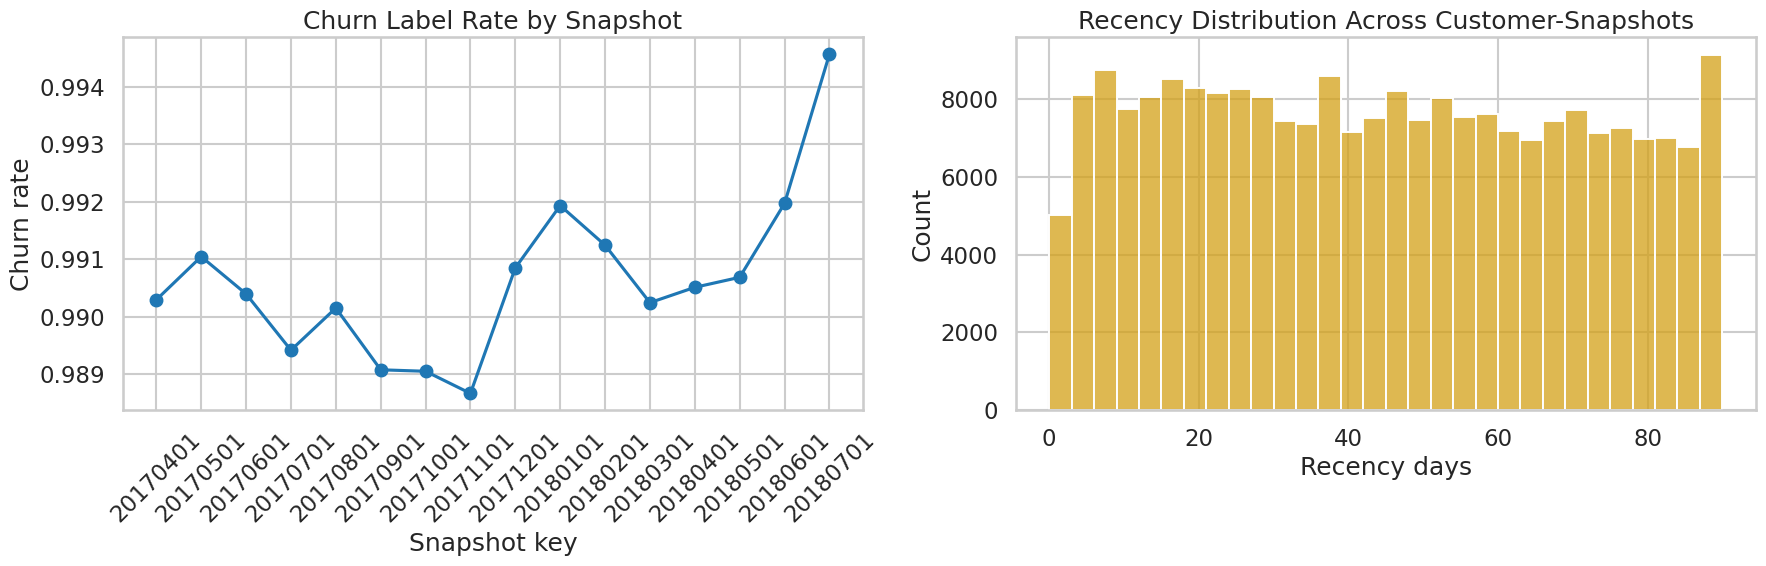

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(range(len(label_by_snapshot)), label_by_snapshot['churn_rate'], marker='o', color='#1f77b4')
axes[0].set_title('Churn Label Rate by Snapshot')
axes[0].set_xlabel('Snapshot key')
axes[0].set_ylabel('Churn rate')
axes[0].set_xticks(range(len(label_by_snapshot)))
axes[0].set_xticklabels(label_by_snapshot['snapshot_key'].astype(str), rotation=45)

sns.histplot(feature_matrix['recency_days'], bins=30, ax=axes[1], color='#d4a017')
axes[1].set_title('Recency Distribution Across Customer-Snapshots')
axes[1].set_xlabel('Recency days')

plt.tight_layout()
plt.show()

---
## 3.9. NOTEBOOK CLOSURE

The feature matrix is now persisted and ready for modeling. Two analytical realities deserve attention before NB04 starts:

1. the target is highly imbalanced, which is structurally consistent with a marketplace dominated by one-time or low-frequency buyers;
2. snapshot-based modeling is therefore essential, because a single end-of-history cut would have produced an even narrower training signal.

In NB04, the priority should be to define a temporal split, choose baseline models that can cope with imbalance and compare business-oriented ranking behavior rather than relying only on raw accuracy.